<a href="https://colab.research.google.com/github/Jadhavsakshi7887/1Hacktoberfest2024/blob/main/Vehical_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving converted_jpgs.zip to converted_jpgs.zip


✅ Unzipped successfully to: /content/unzipped_data

🖼️ Found 913 image(s):

/content/unzipped_data/converted_jpgs/18380.jpg
/content/unzipped_data/converted_jpgs/5830.jpg
/content/unzipped_data/converted_jpgs/6580.jpg
/content/unzipped_data/converted_jpgs/3388.jpg
/content/unzipped_data/converted_jpgs/13980.jpg
/content/unzipped_data/converted_jpgs/19105.jpg
/content/unzipped_data/converted_jpgs/3792.jpg
/content/unzipped_data/converted_jpgs/15317.jpg
/content/unzipped_data/converted_jpgs/13888.jpg
/content/unzipped_data/converted_jpgs/1492.jpg
/content/unzipped_data/converted_jpgs/7567.jpg
/content/unzipped_data/converted_jpgs/14404.jpg
/content/unzipped_data/converted_jpgs/19130.jpg
/content/unzipped_data/converted_jpgs/20752.jpg
/content/unzipped_data/converted_jpgs/19755.jpg
/content/unzipped_data/converted_jpgs/14767.jpg
/content/unzipped_data/converted_jpgs/22167.jpg
/content/unzipped_data/converted_jpgs/19180.jpg
/content/unzipped_data/converted_jpgs/4904.jpg
/content/unzipped_d

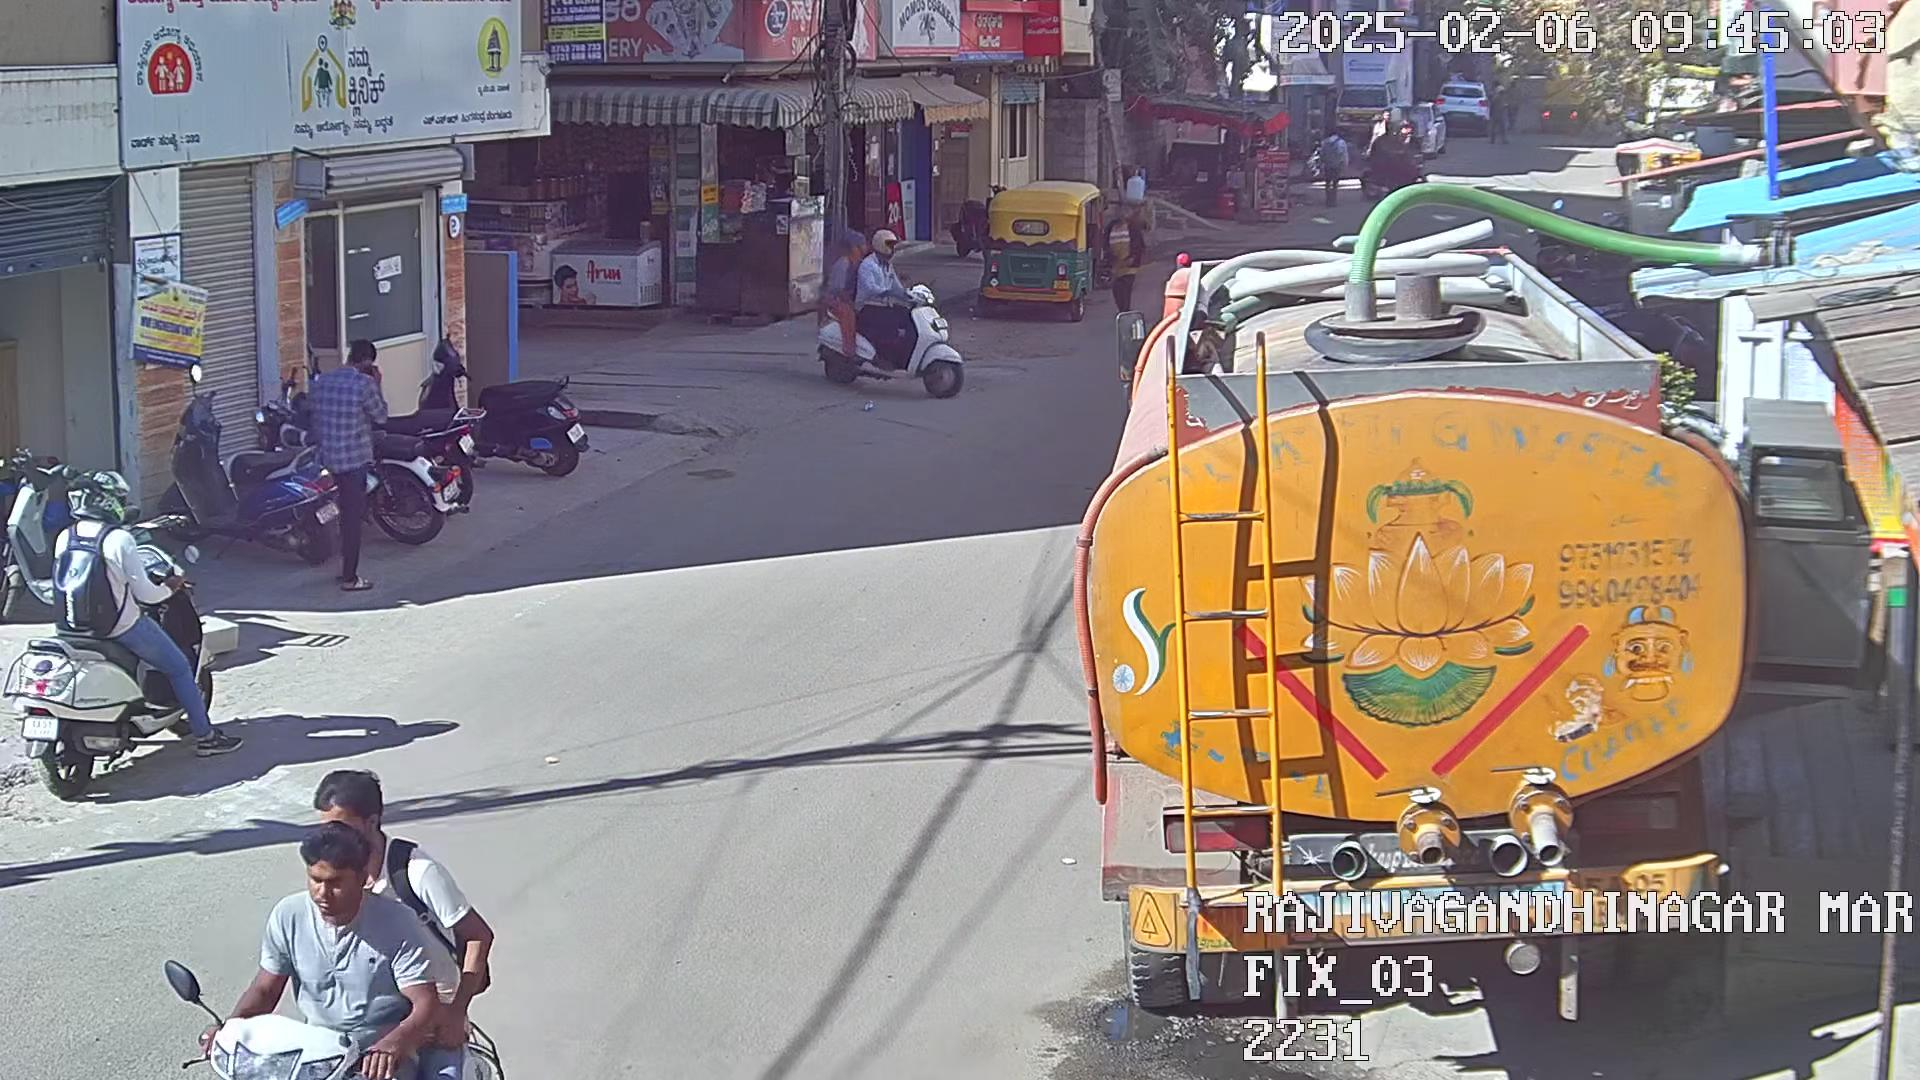

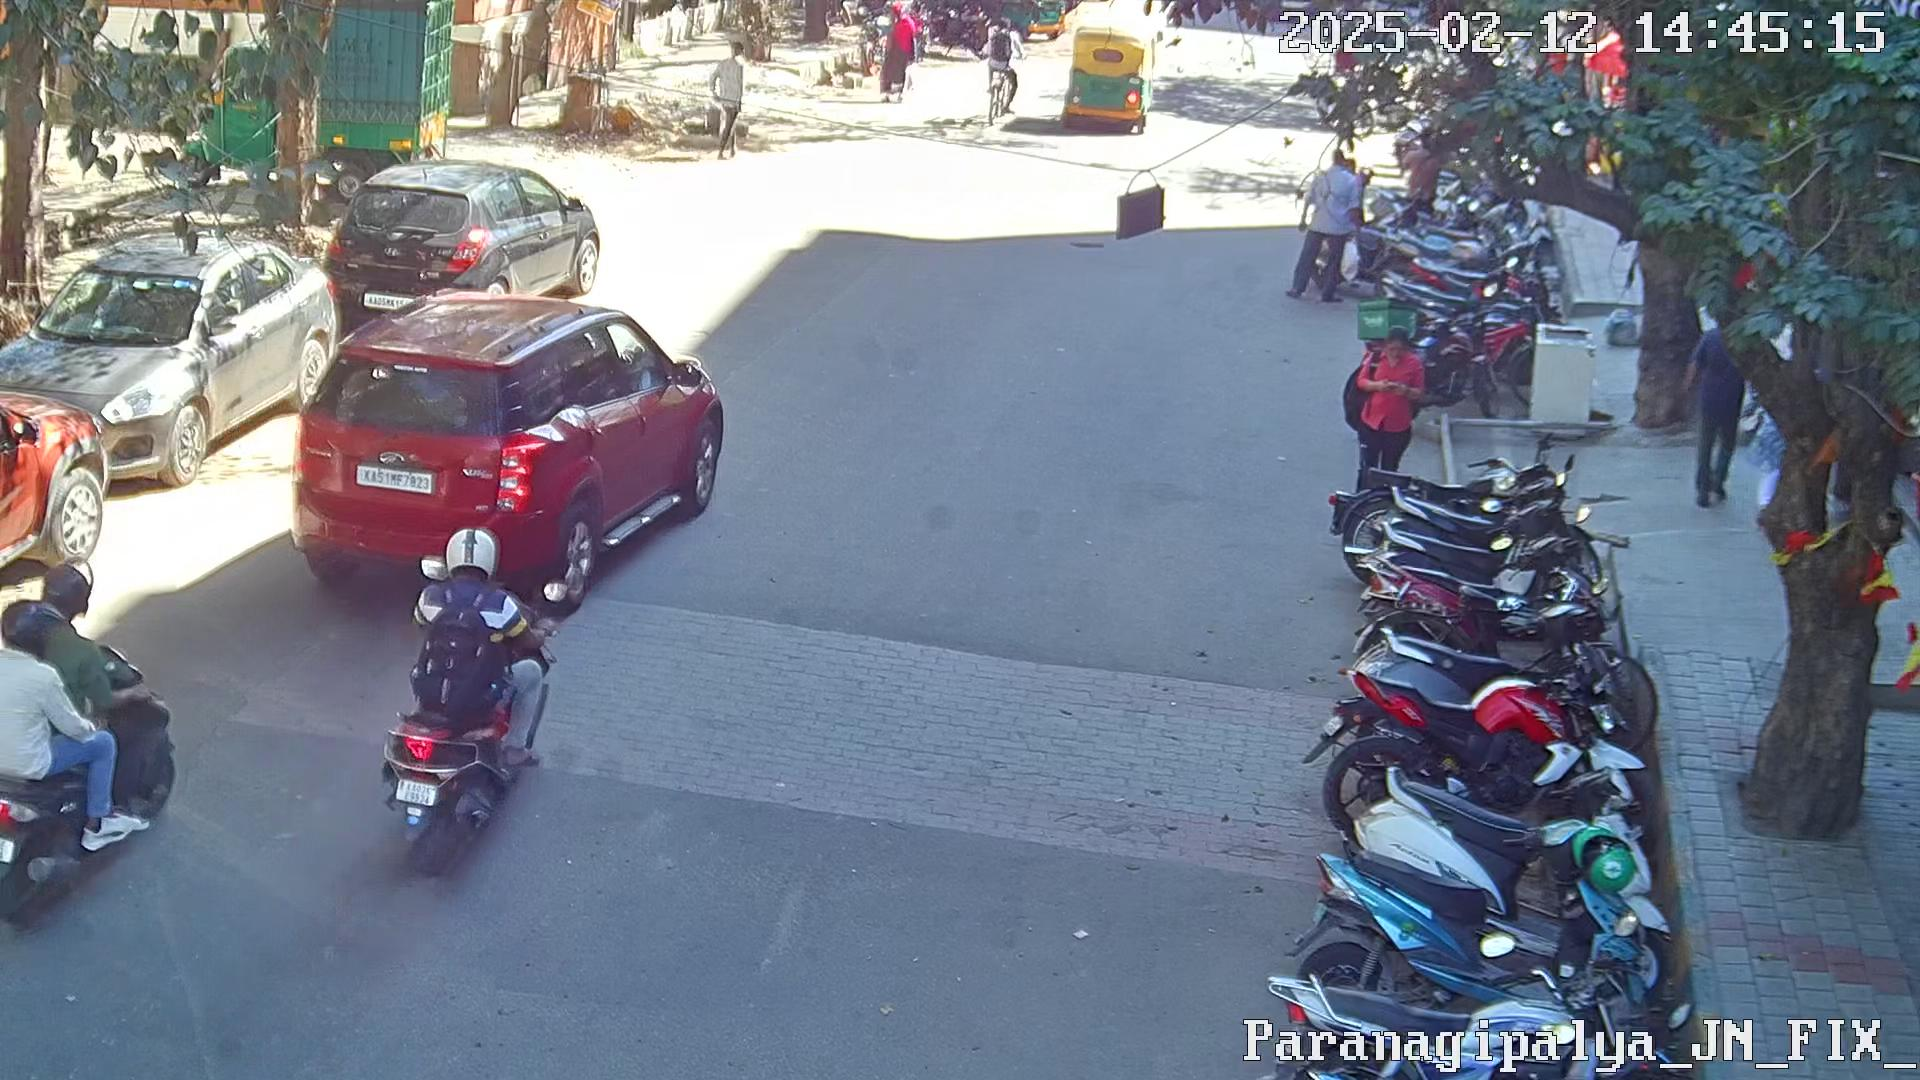

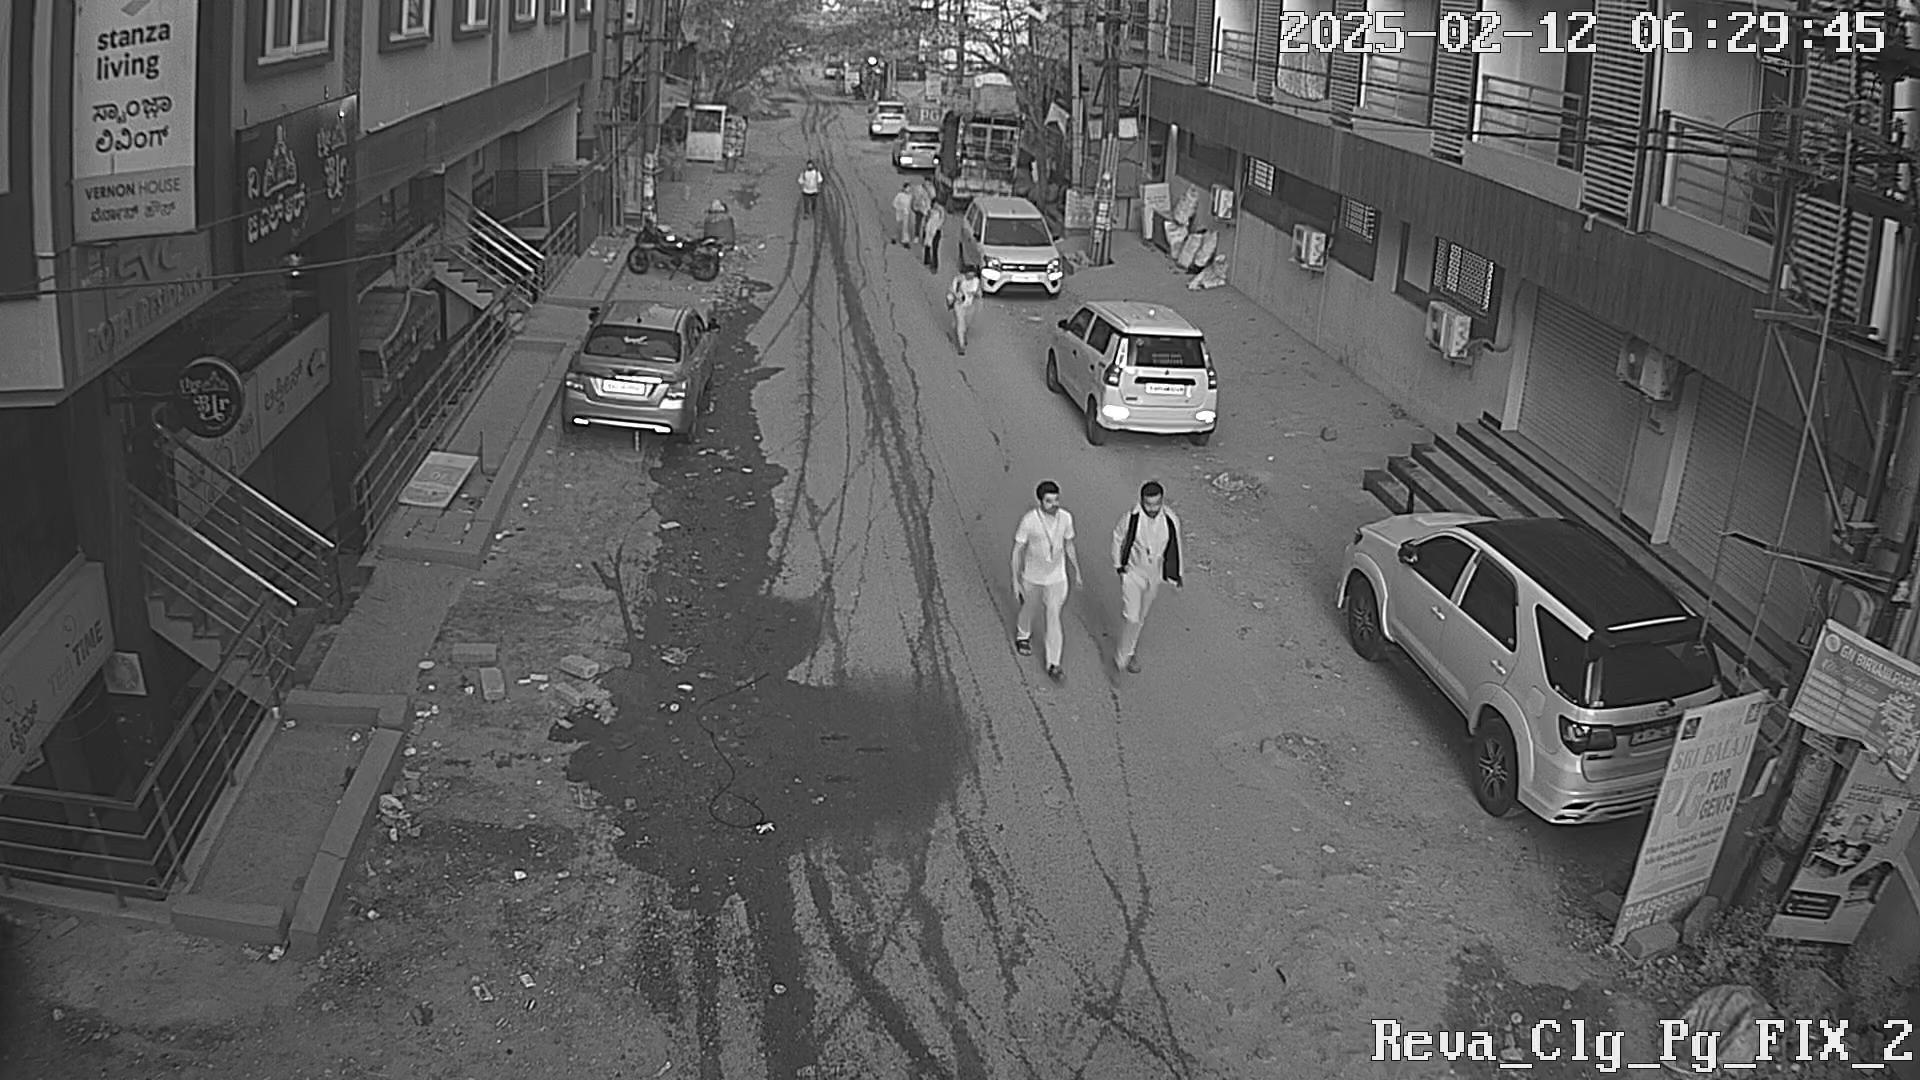

In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt
import cv2
from IPython.display import display, Image

zip_filename = "/content/converted_jpgs.zip"
extract_dir = "/content/unzipped_data"

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Unzipped successfully to: {extract_dir}")
else:
    print(f" Folder already exists: {extract_dir}")

image_extensions = [".jpg", ".jpeg", ".png"]
image_paths = []

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if any(file.lower().endswith(ext) for ext in image_extensions):
            image_paths.append(os.path.join(root, file))

print(f"\nFound {len(image_paths)} image(s):\n")
for path in image_paths:
    print(path)

print("\nPreviewing first 3 images:")
for img_path in image_paths[:3]:
    display(Image(filename=img_path))


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving cleaned_multi_class_coco.json to cleaned_multi_class_coco.json


In [ ]:
import os
import cv2
import json

image_dir = "/content/unzipped_data/converted_jpgs"
json_path = "/content/cleaned_multi_class_coco.json"
output_json = "/content/unzipped_data/annotations_fixed.json"

with open(json_path, "r") as f:
    coco = json.load(f)

for img in coco["images"]:
    path = os.path.join(image_dir, img["file_name"])
    if os.path.exists(path):
        image = cv2.imread(path)
        h, w = image.shape[:2]
        img["width"] = w
        img["height"] = h
    else:
        print(f"Missing file: {img['file_name']}")

with open(output_json, "w") as f:
    json.dump(coco, f, indent=2)

print(f"Fixed JSON saved to: {output_json}")


✅ Fixed JSON saved to: /content/unzipped_data/annotations_fixed.json


In [ ]:
import cv2
import os

image_folder = "/content/unzipped_data/converted_jpgs"

expected_width = 1920
expected_height = 1080

invalid_images = []

for filename in os.listdir(image_folder):
    if filename.lower().endswith(".jpg"):
        img_path = os.path.join(image_folder, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Could not open: {filename}")
            continue

        height, width = img.shape[:2]
        if width != expected_width or height != expected_height:
            print(f"{filename} is {width}x{height} instead of 1920x1080")
            invalid_images.append((filename, width, height))

if not invalid_images:
    print("\nAll images are 1920x1080!")
else:
    print(f"\n{len(invalid_images)} images do not match 1920x1080.")


⚠️ 20596.jpg is 3072x2048 instead of 1920x1080
⚠️ 2138.jpg is 2304x1296 instead of 1920x1080
⚠️ 15030.jpg is 2304x1296 instead of 1920x1080
⚠️ 2005.jpg is 2304x1296 instead of 1920x1080
⚠️ 17930.jpg is 2304x1296 instead of 1920x1080
⚠️ 17517.jpg is 2304x1296 instead of 1920x1080

❌ 6 images do not match 1920x1080.


In [ ]:
import os
import cv2

image_folder = "/content/unzipped_data/converted_jpgs"

expected_width = 1920
expected_height = 1080

resized_count = 0

for filename in os.listdir(image_folder):
    if filename.lower().endswith(".jpg"):
        path = os.path.join(image_folder, filename)
        img = cv2.imread(path)

        if img is None:
            print(f"Cannot read: {filename}")
            continue

        h, w = img.shape[:2]

        if (w, h) != (expected_width, expected_height):
            resized = cv2.resize(img, (expected_width, expected_height))
            cv2.imwrite(path, resized)
            print(f"🔧 Resized: {filename} from {w}x{h} → 1920x1080")
            resized_count += 1

print(f"\nDone. Resized {resized_count} images to 1920x1080.")


🔧 Resized: 20596.jpg from 3072x2048 → 1920x1080
🔧 Resized: 2138.jpg from 2304x1296 → 1920x1080
🔧 Resized: 15030.jpg from 2304x1296 → 1920x1080
🔧 Resized: 2005.jpg from 2304x1296 → 1920x1080
🔧 Resized: 17930.jpg from 2304x1296 → 1920x1080
🔧 Resized: 17517.jpg from 2304x1296 → 1920x1080

✅ Done. Resized 6 images to 1920x1080.


In [ ]:
import cv2
import os

image_folder = "/content/unzipped_data/converted_jpgs"

expected_width = 1920
expected_height = 1080

invalid_images = []

for filename in os.listdir(image_folder):
    if filename.lower().endswith(".jpg"):
        img_path = os.path.join(image_folder, filename)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Could not open: {filename}")
            continue

        height, width = img.shape[:2]
        if width != expected_width or height != expected_height:
            print(f"{filename} is {width}x{height} instead of 1920x1080")
            invalid_images.append((filename, width, height))

if not invalid_images:
    print("\nAll images are 1920x1080!")
else:
    print(f"\n{len(invalid_images)} images do not match 1920x1080.")



🎉 All images are 1920x1080!


In [ ]:
import json
import os
from PIL import Image

json_path = "/content/unzipped_data/annotations_fixed.json"
image_dir = "/content/unzipped_data/converted_jpgs"
output_path = "/content/final_fixed_annotations.json"

with open(json_path, "r") as f:
    coco = json.load(f)

fixed_count = 0

for img in coco["images"]:
    img_path = os.path.join(image_dir, img["file_name"])
    try:
        with Image.open(img_path) as im:
            actual_w, actual_h = im.size
            if img["width"] != actual_w or img["height"] != actual_h:
                print(f"Fixing {img['file_name']} from ({img['width']}, {img['height']}) → ({actual_w}, {actual_h})")
                img["width"] = actual_w
                img["height"] = actual_h
                fixed_count += 1
    except Exception as e:
        print(f"Error loading {img['file_name']}: {e}")

with open(output_path, "w") as f:
    json.dump(coco, f, indent=2)

print(f"\nFixed {fixed_count} entries. Saved to {output_path}")


⚠️ Fixing 17517.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 2005.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 2005.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 20596.jpg from (3072, 2048) → (1920, 1080)
⚠️ Fixing 17517.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 15030.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17930.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17517.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17517.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17517.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 15030.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17930.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 15030.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 2005.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 2005.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 17930.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 15030.jpg from (2304, 1296) → (1920, 1080)
⚠️ Fixing 20596.jpg from (3072, 2048) → (1920, 1080)
⚠️ Fixing 2005.jpg from (2304, 1296) → (1920, 1080